# Polynomial Regression — GK Volatility Prediction

**Task**: Predict next-hour Garman-Klass Volatility (`target_reg`)  
**Models**: Polynomial Regression from scratch + sklearn  
**What is Polynomial Regression?**: Extends linear regression by adding polynomial feature terms — $\hat{y} = w_1x + w_2x^2 + w_3x^3 + \cdots + b$  
This allows the model to capture **non-linear** relationships in the data.  
**Evaluation**: Loss, R², Confusion Matrix, Accuracy, Precision, Sensitivity, Specificity, TNR, F1, ROC & AUC, Performance Curves


---
## 1. Setup & Load Data

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, os, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_curve, auc
)

# File paths
BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), '..'))
TRAIN_FILE    = os.path.join(BASE_DIR, 'data', 'final_training_data_regression_train.csv')
TEST_FILE     = os.path.join(BASE_DIR, 'data', 'final_training_data_regression_test.csv')
FEATURES_FILE = os.path.join(BASE_DIR, 'data', 'selected_features_regression.json')
SCALER_FILE   = os.path.join(BASE_DIR, 'models', 'scaler_regression.pkl')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')
RESULTS_DIR   = os.path.join(BASE_DIR, 'results')
PLOTS_DIR     = os.path.join(BASE_DIR, 'plots')
RESULTS_CSV   = os.path.join(RESULTS_DIR, 'regression_results.csv')

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)

# compute regression metrics 
def compute_metrics(model_name, y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-10)))) * 100
    print(f"\n{'='*55}\n  {model_name}\n{'='*55}")
    print(f"  MSE     : {mse:.8f}")
    print(f"  RMSE    : {rmse:.8f}")
    print(f"  MAE     : {mae:.8f}")
    print(f"  R²      : {r2:.4f}")
    print(f"  MAPE(%) : {mape:.4f}")
    print(f"{'='*55}")
    return {'model': model_name, 'mse': round(mse,8), 'rmse': round(rmse,8),
            'mae': round(mae,8), 'r2': round(r2,4), 'mape': round(mape,4)}

# results to CSV 
def save_results(metrics_dict):
    row = pd.DataFrame([metrics_dict])
    if os.path.exists(RESULTS_CSV):
        existing = pd.read_csv(RESULTS_CSV)
        existing = existing[existing['model'] != metrics_dict['model']]
        row = pd.concat([existing, row], ignore_index=True)
    row.to_csv(RESULTS_CSV, index=False)
    print(f"Results saved → {RESULTS_CSV}")

# plot & save confusion matrix 
def plot_confusion_matrix(y_true, y_pred, model_name, save_path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
                xticklabels=['Low Vol','High Vol'],
                yticklabels=['Low Vol','High Vol'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

print('Libraries loaded')
print(f'BASE_DIR    : {BASE_DIR}')
print(f'RESULTS_DIR : {RESULTS_DIR}')
print(f'PLOTS_DIR   : {PLOTS_DIR}')


Libraries loaded
BASE_DIR    : d:\ML\Project-Including model training\cryptoflow
RESULTS_DIR : d:\ML\Project-Including model training\cryptoflow\results
PLOTS_DIR   : d:\ML\Project-Including model training\cryptoflow\plots


In [23]:
train = pd.read_csv(TRAIN_FILE, parse_dates=['open time'])
test  = pd.read_csv(TEST_FILE,  parse_dates=['open time'])

with open(FEATURES_FILE) as f:
    feature_cols = json.load(f)

if os.path.exists(SCALER_FILE):
    with open(SCALER_FILE, 'rb') as f:
        scaler = pickle.load(f)
    X_train = scaler.transform(train[feature_cols].values)
    X_test  = scaler.transform(test[feature_cols].values)
else:
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(train[feature_cols].values)
    X_test  = scaler.transform(test[feature_cols].values)

y_train = train['target_reg'].values
y_test  = test['target_reg'].values

val_cut = int(len(X_train) * 0.85)
X_tr, X_val = X_train[:val_cut], X_train[val_cut:]
y_tr, y_val = y_train[:val_cut], y_train[val_cut:]

print(f'Train: {len(train):,} rows | Test: {len(test):,} rows')
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Features ({len(feature_cols)}): {feature_cols}')


Train: 60,260 rows | Test: 10,635 rows
X_train: (60260, 10) | X_test: (10635, 10)
Features (10): ['hl_range_pct', 'gk_avg_6h', 'gk_lag_6h', 'hour_cos', 'gk_avg_3h', 'gk_lag_1h', 'trade_intensity', 'log_return_3h', 'log_return_6h', 'atr_lag_3h']


---
## 2. Data Analysis

=== Target Variable Statistics ===
              Train          Test
count  60260.000000  10635.000000
mean       0.006115      0.003886
std        0.005756      0.003113
min        0.000000      0.000229
25%        0.002852      0.001998
50%        0.004590      0.003076
75%        0.007497      0.004795
max        0.213448      0.085401


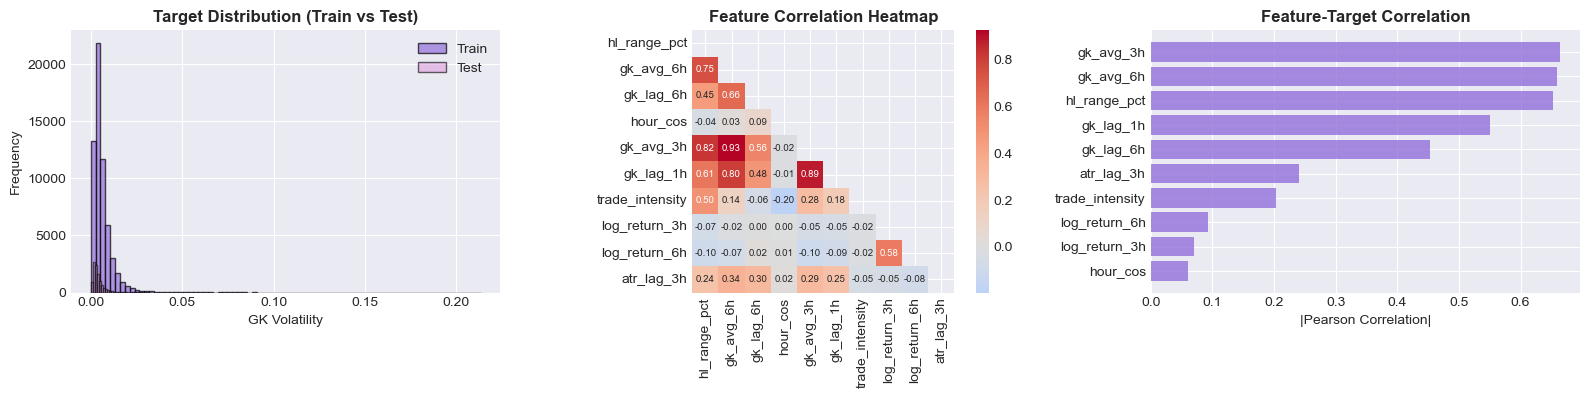

In [24]:
print('=== Target Variable Statistics ===')
print(pd.DataFrame({'Train': pd.Series(y_train).describe(),
                    'Test' : pd.Series(y_test).describe()}).round(8))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(y_train, bins=80, alpha=0.7, color='mediumpurple', edgecolor='black', label='Train')
axes[0].hist(y_test,  bins=80, alpha=0.6, color='plum',         edgecolor='black', label='Test')
axes[0].set_xlabel('GK Volatility'); axes[0].set_ylabel('Frequency')
axes[0].set_title('Target Distribution (Train vs Test)', fontweight='bold')
axes[0].legend()

df_feat = pd.DataFrame(X_train, columns=feature_cols)
corr = df_feat.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[1], cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7}, square=True)
axes[1].set_title('Feature Correlation Heatmap', fontweight='bold')

feat_target_corr = df_feat.corrwith(pd.Series(y_train)).abs().sort_values(ascending=True)
axes[2].barh(feat_target_corr.index, feat_target_corr.values, color='mediumpurple', alpha=0.8)
axes[2].set_xlabel('|Pearson Correlation|')
axes[2].set_title('Feature-Target Correlation', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'poly_data_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 3. Polynomial Feature Expansion — From Scratch

**Key idea**: Transform the original features $x_1, x_2, ..., x_n$ into polynomial terms:

$$[x_1, x_2, x_1^2, x_2^2, x_1 x_2, ...]$$

Then apply standard multiple regression on the expanded features.  
The model is still **linear in the parameters** — only the features are transformed.

**Degree selection**: We use degree=2 (quadratic) to avoid explosion of feature count.  
With $n$ features and degree $d$, the expanded size = $\binom{n+d}{d}$


In [25]:
class PolynomialFeaturesscratch:
    """
    Polynomial feature expansion from scratch.
    Generates all combinations of features up to the given degree.
    Degree 2 with n features → n + n*(n+1)/2 new features (plus bias).
    """
    def __init__(self, degree=2, include_bias=False):
        self.degree       = degree
        self.include_bias = include_bias
        self.n_features_  = None
        self.powers_      = None   # list of exponent tuples for each output feature

    def _generate_powers(self, n_features):
        """Generate all exponent combinations up to self.degree."""
        from itertools import combinations_with_replacement
        powers = []
        for d in range(1, self.degree + 1):
            for combo in combinations_with_replacement(range(n_features), d):
                exp = [0] * n_features
                for idx in combo:
                    exp[idx] += 1
                powers.append(tuple(exp))
        return powers

    def fit(self, X):
        self.n_features_ = X.shape[1]
        self.powers_     = self._generate_powers(self.n_features_)
        n_out = len(self.powers_) + (1 if self.include_bias else 0)
        print(f"  Polynomial degree={self.degree}: {self.n_features_} → {n_out} features")
        return self

    def transform(self, X):
        n_samples = X.shape[0]
        cols = []
        if self.include_bias:
            cols.append(np.ones((n_samples, 1)))
        for exp in self.powers_:
            col = np.ones(n_samples)
            for fi, e in enumerate(exp):
                if e > 0:
                    col = col * (X[:, fi] ** e)
            cols.append(col.reshape(-1, 1))
        return np.hstack(cols)

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def get_feature_names(self, feature_names=None):
        names = feature_names or [f'x{i}' for i in range(self.n_features_)]
        result = ['1'] if self.include_bias else []
        for exp in self.powers_:
            parts = []
            for fi, e in enumerate(exp):
                if e == 1: parts.append(names[fi])
                elif e > 1: parts.append(f'{names[fi]}^{e}')
            result.append(' '.join(parts) if parts else '1')
        return result


class PolynomialRegressionScratch:
    """
    Polynomial Regression from scratch.
    Step 1: Expand features using PolynomialFeaturescratch
    Step 2: Fit Multiple Regression via Normal Equation or Gradient Descent
    """
    def __init__(self, degree=2, method='normal', learning_rate=0.001,
                 n_epochs=100, batch_size=256, verbose=True):
        self.degree      = degree
        self.method      = method
        self.lr          = learning_rate
        self.n_epochs    = n_epochs
        self.batch_size  = batch_size
        self.verbose     = verbose
        self.poly        = PolynomialFeaturesscratch(degree=degree, include_bias=False)
        self.weights     = None
        self.bias        = None
        self.train_losses = []
        self.val_losses   = []

    def _expand(self, X, fit=False):
        if fit:
            return self.poly.fit_transform(X)
        return self.poly.transform(X)

    def fit(self, X, y, X_val=None, y_val=None):
        print(f"Expanding features to degree={self.degree}...")
        Xp = self._expand(X, fit=True)
        Xp_val = self._expand(X_val) if X_val is not None else None
        n, p = Xp.shape
        print(f"Fitting Polynomial Regression on {p} expanded features (method={self.method})...")

        if self.method == 'normal':
            Xb = np.hstack([np.ones((n, 1)), Xp])
            theta, _, _, _ = np.linalg.lstsq(Xb, y, rcond=None)
            self.bias    = float(theta[0])
            self.weights = theta[1:]
            self.train_losses = [float(np.mean((self.predict(X) - y) ** 2))]
            print(f"  Normal Equation solved. Train MSE: {self.train_losses[0]:.8f}")

        elif self.method == 'gradient_descent':
            self.weights      = np.zeros(p)
            self.bias         = 0.0
            self.train_losses = []
            self.val_losses   = []

            for epoch in range(self.n_epochs):
                idx = np.random.permutation(n)
                Xs, ys = Xp[idx], y[idx]
                for start in range(0, n, self.batch_size):
                    Xb = Xs[start:start+self.batch_size]
                    yb = ys[start:start+self.batch_size]
                    nb = len(yb)
                    err = Xb @ self.weights + self.bias - yb
                    self.weights -= self.lr * (2/nb) * (Xb.T @ err)
                    self.bias    -= self.lr * (2/nb) * err.sum()

                train_mse = float(np.mean((self.predict(X) - y) ** 2))
                self.train_losses.append(train_mse)
                if Xp_val is not None:
                    val_mse = float(np.mean((Xp_val @ self.weights + self.bias - y_val) ** 2))
                    self.val_losses.append(val_mse)

                if self.verbose and (epoch + 1) % 10 == 0:
                    msg = f'  Epoch {epoch+1:3d}/{self.n_epochs} — Train MSE: {train_mse:.8f}'
                    if self.val_losses:
                        msg += f' | Val MSE: {self.val_losses[-1]:.8f}'
                    print(msg)
        return self

    def predict(self, X):
        Xp = self._expand(X)
        return Xp @ self.weights + self.bias

    def get_coefficients(self, feature_names=None):
        names = self.poly.get_feature_names(feature_names)
        return pd.Series(self.weights, index=names).sort_values(key=abs, ascending=False)

print('PolynomialRegressionScratch defined')


PolynomialRegressionScratch defined


---
## 4. Degree Selection

=== Degree Selection (val MSE) ===
Expanding features to degree=2...
  Polynomial degree=2: 10 → 65 features
Fitting Polynomial Regression on 65 expanded features (method=normal)...
  Normal Equation solved. Train MSE: 0.00001702
  degree=2  expanded_features=65  val_MSE=0.00000781
Expanding features to degree=3...
  Polynomial degree=3: 10 → 285 features
Fitting Polynomial Regression on 285 expanded features (method=normal)...
  Normal Equation solved. Train MSE: 0.00001580
  degree=3  expanded_features=285  val_MSE=0.00000802

Best degree: 2


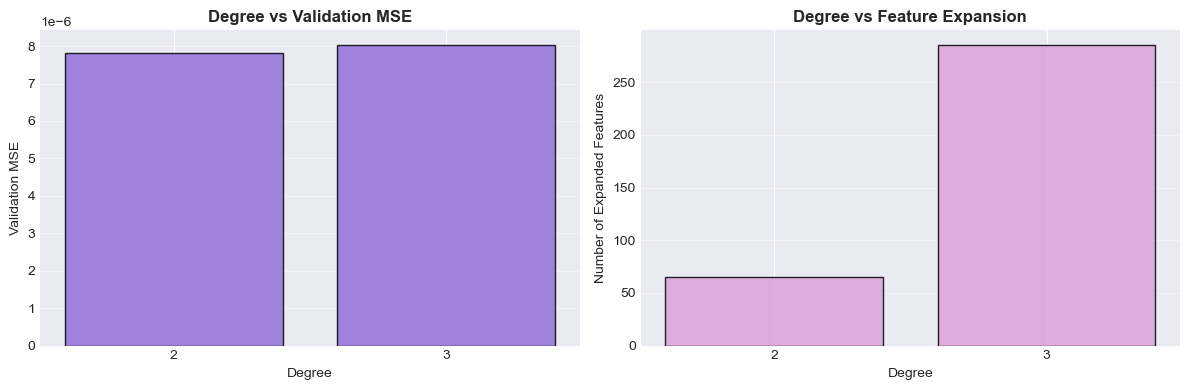

In [26]:
print('=== Degree Selection (val MSE) ===')
degrees = [2, 3]
degree_results = []

for d in degrees:
    m = PolynomialRegressionScratch(degree=d, method='normal', verbose=False)
    m.fit(X_tr, y_tr)
    val_mse = float(mean_squared_error(y_val, m.predict(X_val)))
    n_feats = len(m.poly.powers_)
    degree_results.append({'degree': d, 'val_mse': val_mse, 'n_features': n_feats})
    print(f'  degree={d}  expanded_features={n_feats}  val_MSE={val_mse:.8f}')

df_deg    = pd.DataFrame(degree_results)
best_deg  = int(df_deg.loc[df_deg['val_mse'].idxmin(), 'degree'])
print(f'\nBest degree: {best_deg}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar([str(d) for d in degrees], df_deg['val_mse'],
            color='mediumpurple', edgecolor='black', alpha=0.85)
axes[0].set_xlabel('Degree'); axes[0].set_ylabel('Validation MSE')
axes[0].set_title('Degree vs Validation MSE', fontweight='bold')
axes[0].grid(axis='y', alpha=0.4)

axes[1].bar([str(d) for d in degrees], df_deg['n_features'],
            color='plum', edgecolor='black', alpha=0.85)
axes[1].set_xlabel('Degree'); axes[1].set_ylabel('Number of Expanded Features')
axes[1].set_title('Degree vs Feature Expansion', fontweight='bold')
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'poly_degree_selection.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 5. Train Polynomial Regression — From Scratch

In [27]:
# Normal Equation
poly_normal = PolynomialRegressionScratch(degree=best_deg, method='normal', verbose=True)
poly_normal.fit(X_train, y_train)
y_pred_train_normal = poly_normal.predict(X_train)
y_pred_test_normal  = poly_normal.predict(X_test)
print('\nNormal Equation done')
print(f'Expanded features: {len(poly_normal.poly.powers_)}')


Expanding features to degree=2...
  Polynomial degree=2: 10 → 65 features
Fitting Polynomial Regression on 65 expanded features (method=normal)...
  Normal Equation solved. Train MSE: 0.00001562

Normal Equation done
Expanded features: 65


In [28]:
# Gradient Descent
poly_gd = PolynomialRegressionScratch(degree=best_deg, method='gradient_descent',
                                       learning_rate=1e-7, n_epochs=200,
                                       batch_size=256, verbose=True)
poly_gd.fit(X_tr, y_tr, X_val=X_val, y_val=y_val)
y_pred_train_gd = poly_gd.predict(X_train)
y_pred_test_gd  = poly_gd.predict(X_test)
print('Gradient Descent done')

Expanding features to degree=2...
  Polynomial degree=2: 10 → 65 features
Fitting Polynomial Regression on 65 expanded features (method=gradient_descent)...
  Epoch  10/200 — Train MSE: 0.00007259 | Val MSE: 0.00003254
  Epoch  20/200 — Train MSE: 0.00006958 | Val MSE: 0.00003200
  Epoch  30/200 — Train MSE: 0.00006752 | Val MSE: 0.00003155
  Epoch  40/200 — Train MSE: 0.00006611 | Val MSE: 0.00003118
  Epoch  50/200 — Train MSE: 0.00006511 | Val MSE: 0.00003088
  Epoch  60/200 — Train MSE: 0.00006439 | Val MSE: 0.00003062
  Epoch  70/200 — Train MSE: 0.00006386 | Val MSE: 0.00003040
  Epoch  80/200 — Train MSE: 0.00006345 | Val MSE: 0.00003020
  Epoch  90/200 — Train MSE: 0.00006313 | Val MSE: 0.00003005
  Epoch 100/200 — Train MSE: 0.00006286 | Val MSE: 0.00002990
  Epoch 110/200 — Train MSE: 0.00006263 | Val MSE: 0.00002976
  Epoch 120/200 — Train MSE: 0.00006243 | Val MSE: 0.00002964
  Epoch 130/200 — Train MSE: 0.00006224 | Val MSE: 0.00002952
  Epoch 140/200 — Train MSE: 0.000062

---
## 6. Polynomial Regression — sklearn

In [29]:
from sklearn.preprocessing import PolynomialFeatures as SklearnPolyFeatures

poly_sk_transformer = SklearnPolyFeatures(degree=best_deg, include_bias=False)
X_train_poly = poly_sk_transformer.fit_transform(X_train)
X_test_poly  = poly_sk_transformer.transform(X_test)

print(f'sklearn expanded: {X_train.shape[1]} → {X_train_poly.shape[1]} features')

poly_sk = LinearRegression()
poly_sk.fit(X_train_poly, y_train)
y_pred_train_sk = poly_sk.predict(X_train_poly)
y_pred_test_sk  = poly_sk.predict(X_test_poly)
print('Polynomial Regression (sklearn) done')

print('\nScratch vs sklearn R² comparison:')
print(f'  Normal Eq : {r2_score(y_test, y_pred_test_normal):.4f}')
print(f'  GD        : {r2_score(y_test, y_pred_test_gd):.4f}')
print(f'  sklearn   : {r2_score(y_test, y_pred_test_sk):.4f}')


sklearn expanded: 10 → 65 features
Polynomial Regression (sklearn) done

Scratch vs sklearn R² comparison:
  Normal Eq : 0.4011
  GD        : -1.2047
  sklearn   : 0.4011


---
## 7. Loss & Regression Metrics

In [30]:
models_pred = {
    f'Poly Normal (scratch, deg={best_deg})': (y_pred_train_normal, y_pred_test_normal),
    f'Poly GD (scratch, deg={best_deg})'    : (y_pred_train_gd,     y_pred_test_gd),
    f'Poly sklearn (deg={best_deg})'        : (y_pred_train_sk,     y_pred_test_sk),
}

all_metrics = {}
for name, (y_tr_p, y_te_p) in models_pred.items():
    all_metrics[name] = compute_metrics(name, y_test, y_te_p)

for name, m in all_metrics.items():
    save_results(m)



  Poly Normal (scratch, deg=2)
  MSE     : 0.00000580
  RMSE    : 0.00240905
  MAE     : 0.00155153
  R²      : 0.4011
  MAPE(%) : 52.6607

  Poly GD (scratch, deg=2)
  MSE     : 0.00002136
  RMSE    : 0.00462211
  MAE     : 0.00351762
  R²      : -1.2047
  MAPE(%) : 86.2831

  Poly sklearn (deg=2)
  MSE     : 0.00000580
  RMSE    : 0.00240905
  MAE     : 0.00155153
  R²      : 0.4011
  MAPE(%) : 52.6607
Results saved → d:\ML\Project-Including model training\cryptoflow\results\regression_results.csv
Results saved → d:\ML\Project-Including model training\cryptoflow\results\regression_results.csv
Results saved → d:\ML\Project-Including model training\cryptoflow\results\regression_results.csv


---
## 8. R² Score

=== R² Score Summary ===
Poly Normal (scratch, deg=2)         Train R²: 0.528568  |  Test R²: 0.401099
Poly GD (scratch, deg=2)             Train R²: -0.701697  |  Test R²: -1.204676
Poly sklearn (deg=2)                 Train R²: 0.528568  |  Test R²: 0.401099


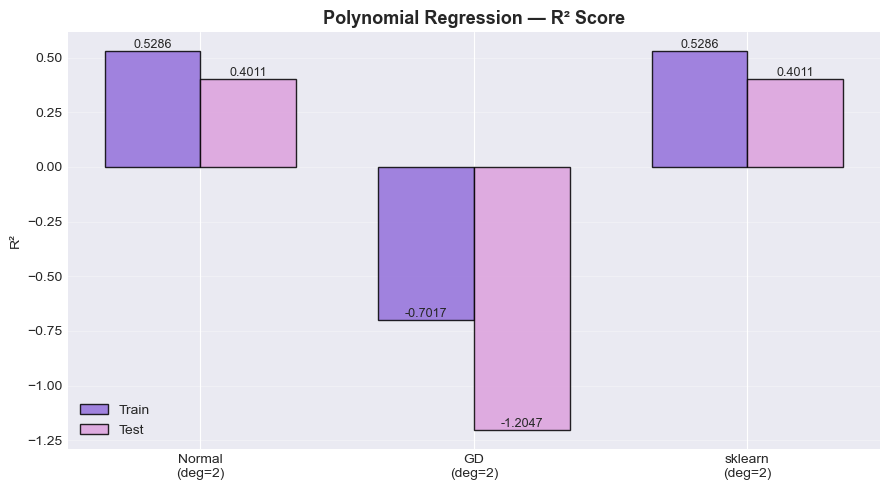

In [31]:
print('=== R² Score Summary ===')
for name, (y_tr_p, y_te_p) in models_pred.items():
    print(f'{name:35s}  Train R²: {r2_score(y_train, y_tr_p):.6f}  |  Test R²: {r2_score(y_test, y_te_p):.6f}')

short         = [f'Normal\n(deg={best_deg})', f'GD\n(deg={best_deg})', f'sklearn\n(deg={best_deg})']
r2_train_vals = [r2_score(y_train, v[0]) for v in models_pred.values()]
r2_test_vals  = [r2_score(y_test,  v[1]) for v in models_pred.values()]

x = np.arange(3); w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x-w/2, r2_train_vals, w, label='Train', color='mediumpurple', alpha=0.85, edgecolor='black')
b2 = ax.bar(x+w/2, r2_test_vals,  w, label='Test',  color='plum',         alpha=0.85, edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(short)
ax.set_ylabel('R²'); ax.set_title('Polynomial Regression — R² Score', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar, v in [(b,vv) for bars,vs in [(b1,r2_train_vals),(b2,r2_test_vals)] for b,vv in zip(bars,vs)]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'poly_r2.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 9. Performance Curves (Loss)

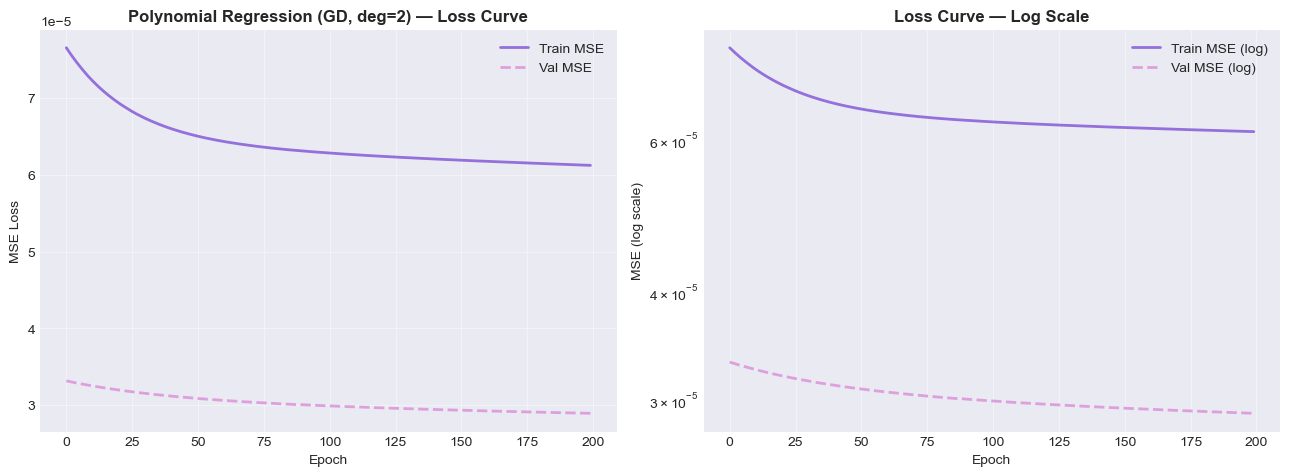

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(poly_gd.train_losses, color='mediumpurple', lw=2, label='Train MSE')
if poly_gd.val_losses:
    axes[0].plot(poly_gd.val_losses, color='plum', lw=2, ls='--', label='Val MSE')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title(f'Polynomial Regression (GD, deg={best_deg}) — Loss Curve', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].semilogy(poly_gd.train_losses, color='mediumpurple', lw=2, label='Train MSE (log)')
if poly_gd.val_losses:
    axes[1].semilogy(poly_gd.val_losses, color='plum', lw=2, ls='--', label='Val MSE (log)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE (log scale)')
axes[1].set_title('Loss Curve — Log Scale', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'poly_loss_curves.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 10. Binarise Predictions for Classification Metrics

In [33]:
threshold  = float(np.median(y_test))
print(f'Binarisation threshold (median GK): {threshold:.6f}')
y_true_bin = (y_test >= threshold).astype(int)

bin_results = {}
for name, (_, y_te_p) in models_pred.items():
    y_pred_bin = (y_te_p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_bin).ravel()
    acc  = accuracy_score(y_true_bin, y_pred_bin)
    prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    sens = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1   = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    fpr, tpr, _ = roc_curve(y_true_bin, y_te_p)
    roc_auc = auc(fpr, tpr)
    bin_results[name] = {
        'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn),
        'Accuracy': round(acc,4), 'Precision': round(prec,4),
        'Sensitivity(TPR)': round(sens,4), 'Specificity(TNR)': round(spec,4),
        'True Negative Rate': round(spec,4), 'F1-Score': round(f1,4),
        'AUC': round(roc_auc,4), '_fpr': fpr, '_tpr': tpr
    }

df_bin = pd.DataFrame({k:{kk:vv for kk,vv in v.items() if not kk.startswith('_')}
                        for k,v in bin_results.items()}).T
print('\n=== Classification Metrics (Binarised from Regression Output) ===')
print(df_bin.to_string())


Binarisation threshold (median GK): 0.003076

=== Classification Metrics (Binarised from Regression Output) ===
                                  TP      TN      FP      FN  Accuracy  Precision  Sensitivity(TPR)  Specificity(TNR)  True Negative Rate  F1-Score     AUC
Poly Normal (scratch, deg=2)  4908.0  2647.0  2670.0   410.0    0.7104     0.6477            0.9229            0.4978              0.4978    0.7612  0.8575
Poly GD (scratch, deg=2)        60.0  5316.0     1.0  5258.0    0.5055     0.9836            0.0113            0.9998              0.9998    0.0223  0.4471
Poly sklearn (deg=2)          4908.0  2647.0  2670.0   410.0    0.7104     0.6477            0.9229            0.4978              0.4978    0.7612  0.8575


---
## 11. Confusion Matrix

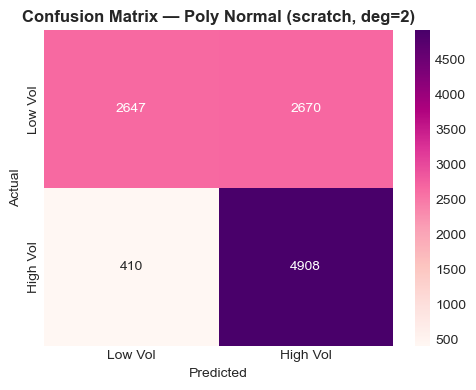

Saved: d:\ML\Project-Including model training\cryptoflow\plots\cm_poly_Poly_Normal_scratch_deg2.png


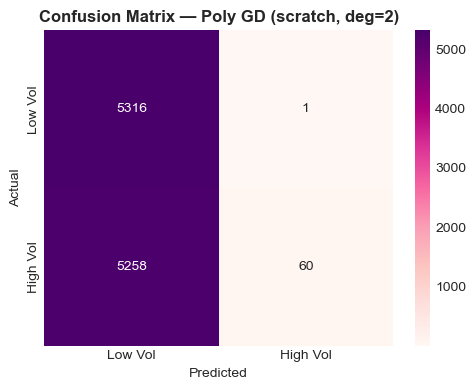

Saved: d:\ML\Project-Including model training\cryptoflow\plots\cm_poly_Poly_GD_scratch_deg2.png


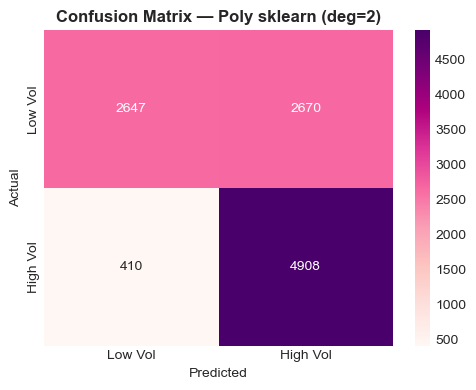

Saved: d:\ML\Project-Including model training\cryptoflow\plots\cm_poly_Poly_sklearn_deg2.png


In [34]:
for name, res in bin_results.items():
    y_pred_bin = (models_pred[name][1] >= threshold).astype(int)
    safe_name  = name.replace(' ', '_').replace('(', '').replace(')', '').replace('=','').replace(',','')
    plot_confusion_matrix(y_true_bin, y_pred_bin, name,
                          os.path.join(PLOTS_DIR, f'cm_poly_{safe_name}.png'))


---
## 12. ROC Curve & AUC

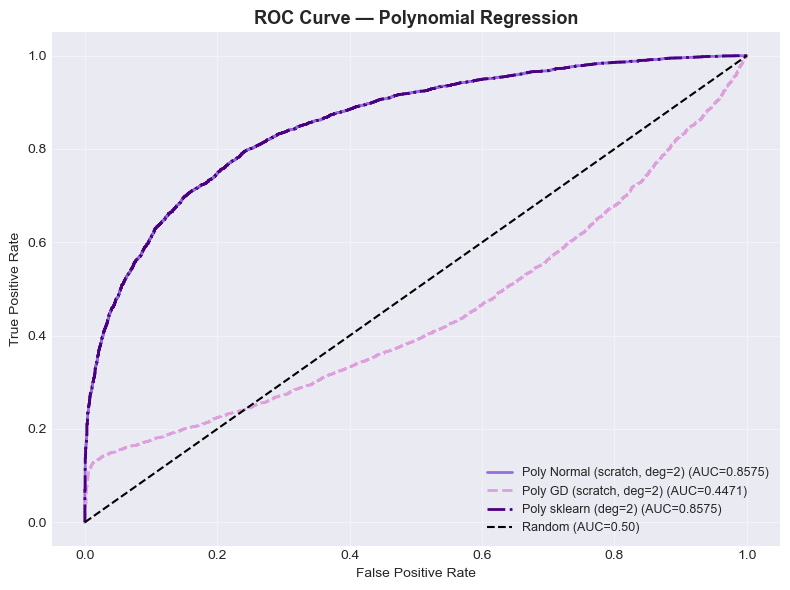

In [35]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['mediumpurple', 'plum', 'indigo']
styles = ['-', '--', '-.']

for (name, res), color, ls in zip(bin_results.items(), colors, styles):
    ax.plot(res['_fpr'], res['_tpr'], color=color, lw=2, ls=ls,
            label=f'{name} (AUC={res["AUC"]:.4f})')

ax.plot([0,1],[0,1],'k--', lw=1.5, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Polynomial Regression', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'poly_roc_curve.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 13. Classification Metric Charts

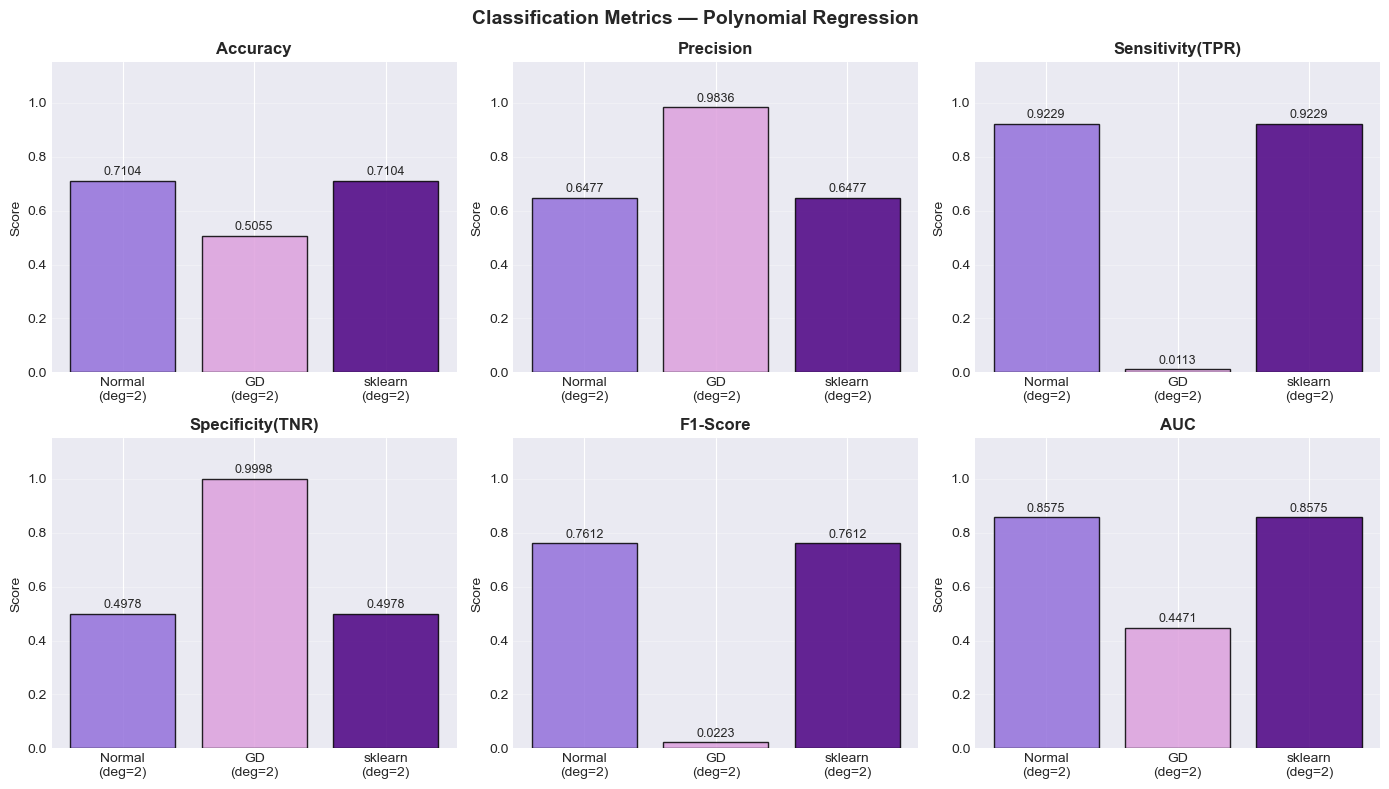

In [36]:
metrics_list = ['Accuracy','Precision','Sensitivity(TPR)','Specificity(TNR)','F1-Score','AUC']
short   = [f'Normal\n(deg={best_deg})', f'GD\n(deg={best_deg})', f'sklearn\n(deg={best_deg})']
palette = ['mediumpurple', 'plum', 'indigo']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, metric in zip(axes, metrics_list):
    vals = [bin_results[m][metric] for m in bin_results]
    bars = ax.bar(short, vals, color=palette, edgecolor='black', alpha=0.85)
    ax.set_ylim(0, 1.15); ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score'); ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Classification Metrics — Polynomial Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'poly_classification_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 14. Actual vs Predicted & Residual Analysis

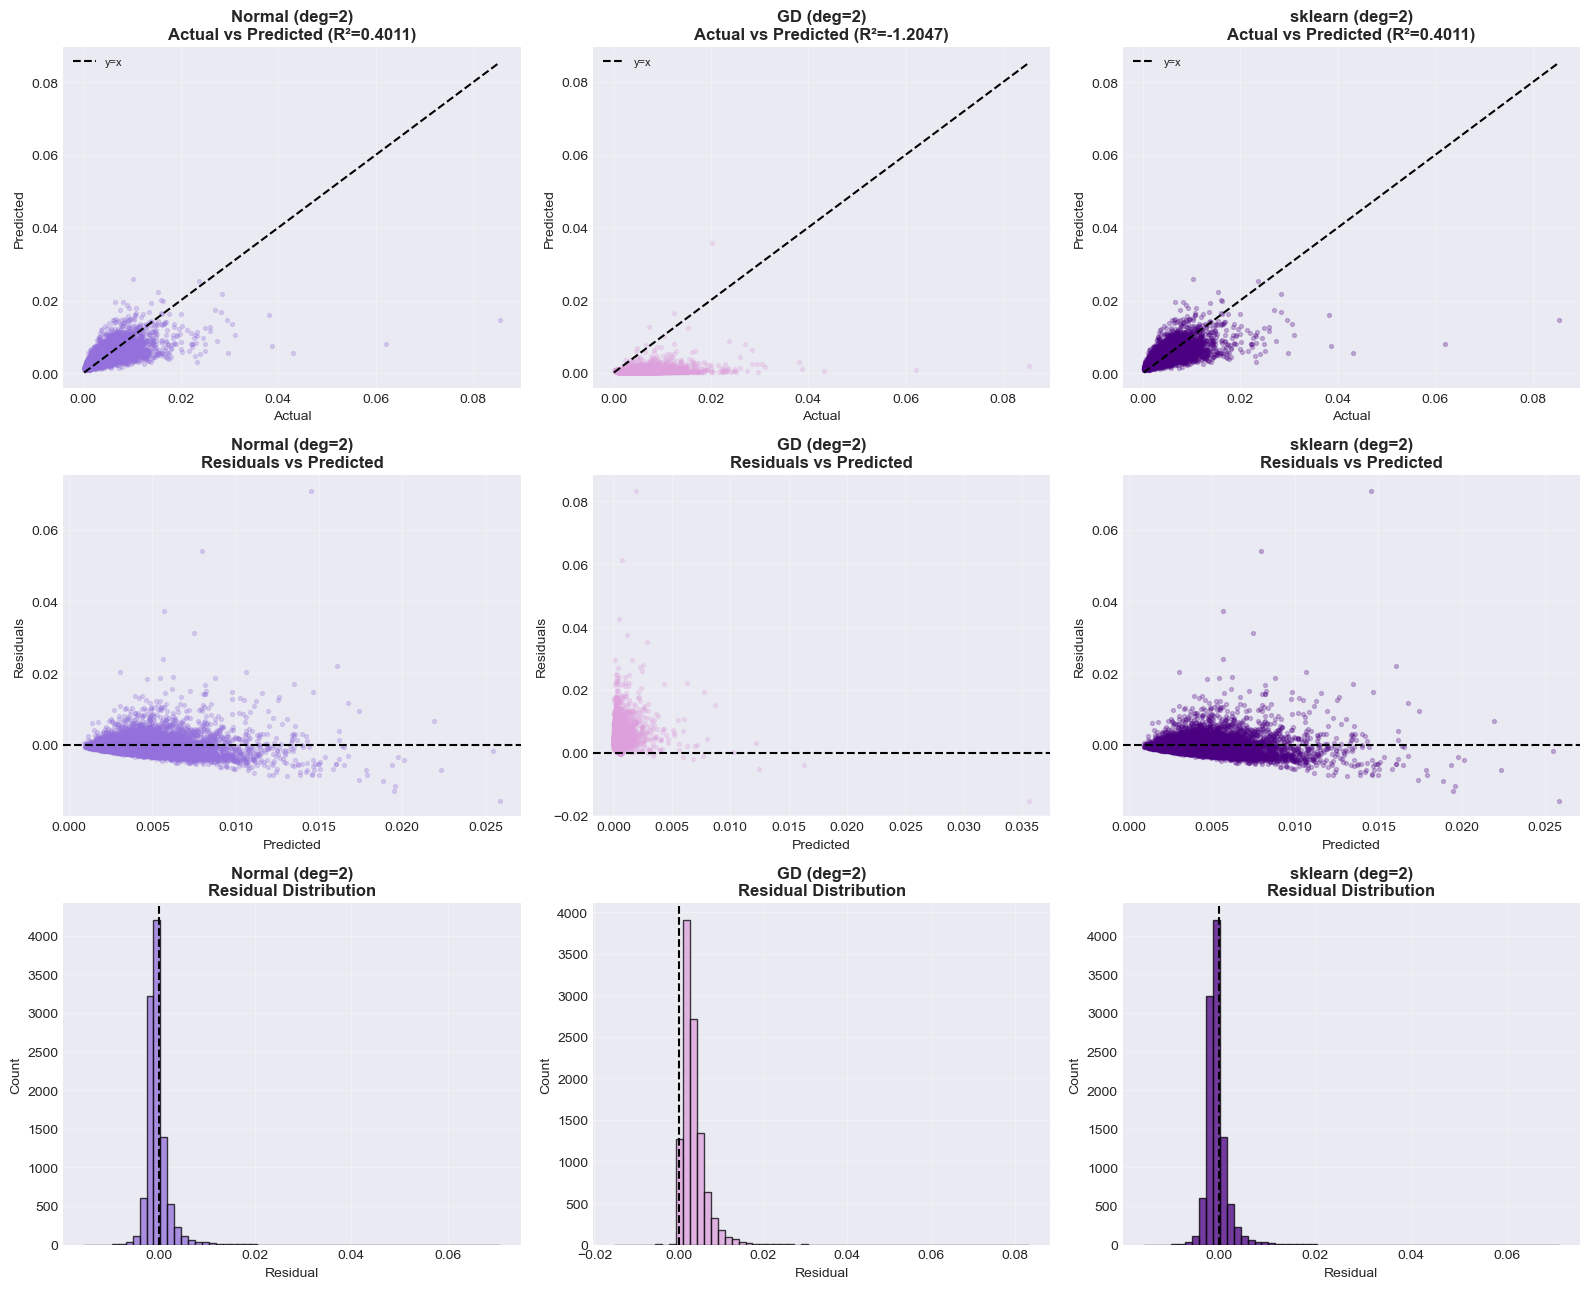

In [37]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
pred_list = [
    (f'Normal (deg={best_deg})', y_pred_test_normal, 'mediumpurple'),
    (f'GD (deg={best_deg})',     y_pred_test_gd,     'plum'),
    (f'sklearn (deg={best_deg})',y_pred_test_sk,     'indigo'),
]

for col, (title, y_pred, color) in enumerate(pred_list):
    axes[0,col].scatter(y_test, y_pred, alpha=0.25, s=8, color=color)
    mn, mx = min(y_test.min(),y_pred.min()), max(y_test.max(),y_pred.max())
    axes[0,col].plot([mn,mx],[mn,mx],'k--',lw=1.5,label='y=x')
    r2 = r2_score(y_test, y_pred)
    axes[0,col].set_title(f'{title}\nActual vs Predicted (R²={r2:.4f})', fontweight='bold')
    axes[0,col].set_xlabel('Actual'); axes[0,col].set_ylabel('Predicted')
    axes[0,col].legend(fontsize=8); axes[0,col].grid(alpha=0.3)

    res = y_test - y_pred
    axes[1,col].scatter(y_pred, res, alpha=0.25, s=8, color=color)
    axes[1,col].axhline(0, color='black', lw=1.5, ls='--')
    axes[1,col].set_title(f'{title}\nResiduals vs Predicted', fontweight='bold')
    axes[1,col].set_xlabel('Predicted'); axes[1,col].set_ylabel('Residuals')
    axes[1,col].grid(alpha=0.3)

    axes[2,col].hist(res, bins=60, color=color, alpha=0.75, edgecolor='black')
    axes[2,col].axvline(0, color='black', lw=1.5, ls='--')
    axes[2,col].set_title(f'{title}\nResidual Distribution', fontweight='bold')
    axes[2,col].set_xlabel('Residual'); axes[2,col].set_ylabel('Count')
    axes[2,col].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'poly_residual_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 15. Time-Series Prediction Plot

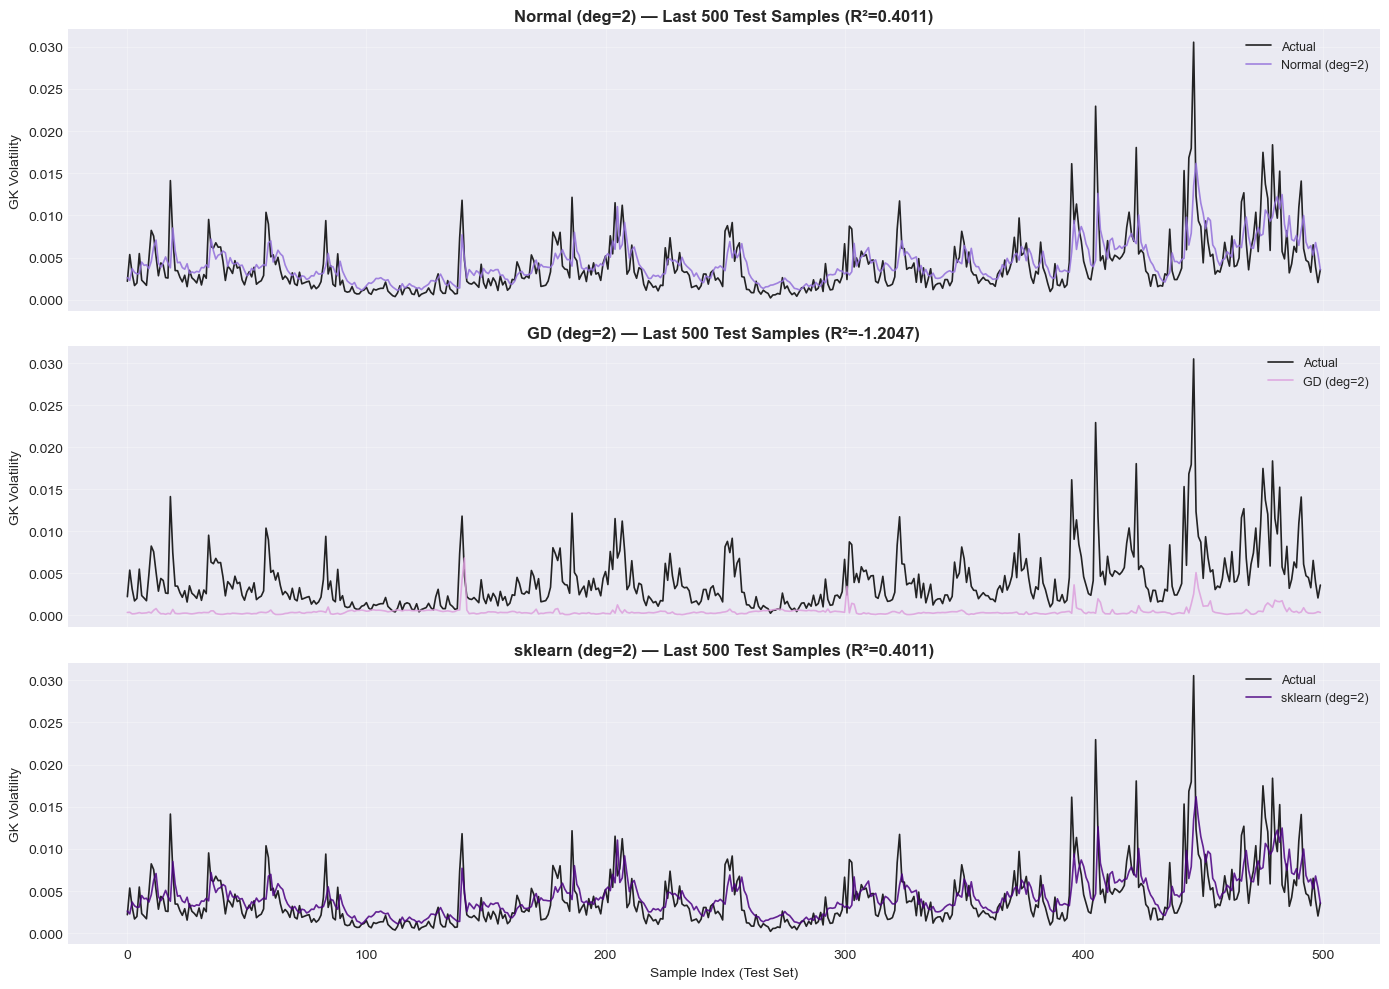

In [38]:
n_plot = 500
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, (title, y_pred, color) in zip(axes, pred_list):
    ax.plot(range(n_plot), y_test[-n_plot:], color='black', lw=1.2, label='Actual', alpha=0.85)
    ax.plot(range(n_plot), y_pred[-n_plot:], color=color,   lw=1.2, label=title,   alpha=0.85)
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{title} — Last {n_plot} Test Samples (R²={r2:.4f})', fontweight='bold')
    ax.set_ylabel('GK Volatility'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

axes[-1].set_xlabel('Sample Index (Test Set)')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'poly_time_series.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 16. Top Polynomial Coefficients

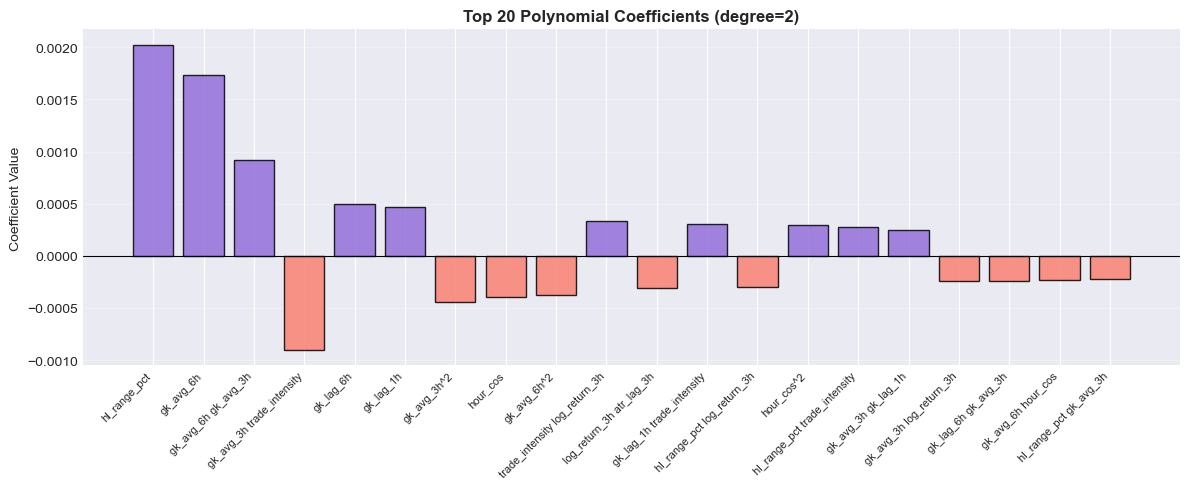

Total expanded features: 65
Top 10 most important polynomial terms:
hl_range_pct                     0.002024
gk_avg_6h                        0.001729
gk_avg_6h gk_avg_3h              0.000917
gk_avg_3h trade_intensity       -0.000904
gk_lag_6h                        0.000499
gk_lag_1h                        0.000466
gk_avg_3h^2                     -0.000446
hour_cos                        -0.000396
gk_avg_6h^2                     -0.000371
trade_intensity log_return_3h    0.000331


In [39]:
coefs = poly_normal.get_coefficients(feature_cols)
top_n = min(20, len(coefs))
coefs_top = coefs.head(top_n)

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = ['mediumpurple' if v > 0 else 'salmon' for v in coefs_top.values]
ax.bar(range(top_n), coefs_top.values, color=bar_colors, edgecolor='black', alpha=0.85)
ax.set_xticks(range(top_n))
ax.set_xticklabels(coefs_top.index, rotation=45, ha='right', fontsize=8)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Coefficient Value')
ax.set_title(f'Top {top_n} Polynomial Coefficients (degree={best_deg})', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'poly_coefficients.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Total expanded features: {len(coefs)}')
print(f'Top 10 most important polynomial terms:')
print(coefs.head(10).to_string())


---
## 17. Save & Load Models

In [40]:
with open(os.path.join(MODELS_DIR, 'poly_normal_scratch.pkl'), 'wb') as f: pickle.dump(poly_normal, f)
with open(os.path.join(MODELS_DIR, 'poly_gd_scratch.pkl'),    'wb') as f: pickle.dump(poly_gd,     f)
with open(os.path.join(MODELS_DIR, 'poly_sklearn.pkl'),        'wb') as f: pickle.dump(poly_sk,     f)
with open(os.path.join(MODELS_DIR, 'poly_transformer.pkl'),    'wb') as f: pickle.dump(poly_sk_transformer, f)
with open(os.path.join(MODELS_DIR, 'poly_scaler.pkl'),         'wb') as f: pickle.dump(scaler,      f)
print('Models saved to:', MODELS_DIR)

with open(os.path.join(MODELS_DIR, 'poly_normal_scratch.pkl'), 'rb') as f: m = pickle.load(f)
print(f'Load verification — R²: {r2_score(y_test, m.predict(X_test)):.6f}  OK')


Models saved to: d:\ML\Project-Including model training\cryptoflow\models
Load verification — R²: 0.401099  OK


---
## 18. Final Summary

In [41]:
print('='*65)
print('  POLYNOMIAL REGRESSION — FINAL SUMMARY')
print('='*65)
print(f'Best degree     : {best_deg}')
print(f'Original features : {len(feature_cols)}')
print(f'Expanded features : {len(poly_normal.poly.powers_)}')
print('\n--- Regression Metrics (Test Set) ---')
for name, m in all_metrics.items():
    print(f'  {name:35s}  MSE={m["mse"]:.4e}  R²={m["r2"]:.4f}')
print('\n--- Classification Metrics (Binarised at median GK) ---')
cols = ['Accuracy','Precision','Sensitivity(TPR)','Specificity(TNR)','F1-Score','AUC']
print(df_bin[cols].to_string())
print('='*65)
print(f'\nAll plots saved to : {PLOTS_DIR}')
print(f'Results saved to   : {RESULTS_CSV}')


  POLYNOMIAL REGRESSION — FINAL SUMMARY
Best degree     : 2
Original features : 10
Expanded features : 65

--- Regression Metrics (Test Set) ---
  Poly Normal (scratch, deg=2)         MSE=5.8000e-06  R²=0.4011
  Poly GD (scratch, deg=2)             MSE=2.1360e-05  R²=-1.2047
  Poly sklearn (deg=2)                 MSE=5.8000e-06  R²=0.4011

--- Classification Metrics (Binarised at median GK) ---
                              Accuracy  Precision  Sensitivity(TPR)  Specificity(TNR)  F1-Score     AUC
Poly Normal (scratch, deg=2)    0.7104     0.6477            0.9229            0.4978    0.7612  0.8575
Poly GD (scratch, deg=2)        0.5055     0.9836            0.0113            0.9998    0.0223  0.4471
Poly sklearn (deg=2)            0.7104     0.6477            0.9229            0.4978    0.7612  0.8575

All plots saved to : d:\ML\Project-Including model training\cryptoflow\plots
Results saved to   : d:\ML\Project-Including model training\cryptoflow\results\regression_results.csv
